# LOAD (INTEGRATE) DATA

In [1]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

import os

In [2]:
# Read data from csv files
data_path = 'dataset/init' # Trỏ đường dẫn vào thư mục con chứa file

weather = pd.read_csv(os.path.join(data_path, 'weather.csv'))

# OVERVIEW

In [3]:
weather.shape

(181960, 10)

In [4]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181960 entries, 0 to 181959
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   province  181960 non-null  object 
 1   max       181960 non-null  int64  
 2   min       181960 non-null  int64  
 3   wind      181960 non-null  int64  
 4   wind_d    181960 non-null  object 
 5   rain      181960 non-null  float64
 6   humidi    181960 non-null  int64  
 7   cloud     181960 non-null  int64  
 8   pressure  181960 non-null  int64  
 9   date      181960 non-null  object 
dtypes: float64(1), int64(6), object(3)
memory usage: 13.9+ MB


**Meaning of the columns** 
1. province: Province (or city) where data recorded  
2. max: Maximum daily temperature (Celsius)  
3. min: Minimum daily temperature (Celsius)  
4. wind: Wind speed (km/h)  
5. wind_d: Wind direction  
6. rain: Amount of rain (mm)  
7. humidi: Humidity (%)  
8. cloud: Cloud coverage (%)  
9. pressure: Air pressure (giá trị quan sát cho thấy nhiều khả năng là hPa/mbar)  
10. date: Date record (yyyy-mm-dd)

In [5]:
weather.head()

,province,max,min,wind,wind_d,rain,humidi,cloud,pressure,date
0,Bac Lieu,27,22,17,NNE,6.9,90,71,1010,2009-01-01
1,Bac Lieu,31,25,20,ENE,0.0,64,24,1010,2010-01-01
2,Bac Lieu,29,24,14,E,0.0,75,45,1008,2011-01-01
3,Bac Lieu,30,24,30,E,0.0,79,52,1012,2012-01-01
4,Bac Lieu,31,25,20,ENE,0.0,70,24,1010,2013-01-01


In [6]:
print(weather.isnull().sum())

province    0
max         0
min         0
wind        0
wind_d      0
rain        0
humidi      0
cloud       0
pressure    0
date        0
dtype: int64


In [7]:
print("\nNumber of duplicate rows:", weather.duplicated().sum())


Number of duplicate rows: 0


# CLEAN DATA

## Equate the two values: Ha Noi and HaNoi in the Province column

In [8]:
weather['province'] = weather['province'].replace('Hanoi', 'Ha Noi')
print(f"Total number of provinces/cities after merger: {weather['province'].nunique()}")

Total number of provinces/cities after merger: 39


## Convert the date column to date and time format and set it as the index

In [9]:
weather['date'] = pd.to_datetime(weather['date'])
weather.set_index('date', inplace=True)
print(f"Date range: {weather.index.min()} to {weather.index.max()}")

Date range: 2009-01-01 00:00:00 to 2021-06-18 00:00:00


## Check for missing dates

In [10]:
# Ensure the time series is not broken for each province
missing_dates = []
for prov in weather['province'].unique():
    prov_data = weather[weather['province'] == prov]
    # Create a standard date range from min to max
    expected_dates = pd.date_range(start=prov_data.index.min(), end=prov_data.index.max())
    # Find missing dates
    missing = expected_dates.difference(prov_data.index)
    if len(missing) > 0:
        missing_dates.append((prov, len(missing)))

if missing_dates:
    print("Provinces with missing dates:", missing_dates)
else:
    print("No missing dates in the data.")

Provinces with missing dates: [('Bac Lieu', 3), ('Ho Chi Minh City', 3), ('Tam Ky', 3), ('Ben Tre', 3), ('Hoa Binh', 3), ('Tan An', 3), ('Bien Hoa', 3), ('Hong Gai', 3), ('Thai Nguyen', 3), ('Buon Me Thuot', 3), ('Hue', 3), ('Thanh Hoa', 3), ('Ca Mau', 3), ('Long Xuyen', 3), ('Tra Vinh', 3), ('Cam Pha', 3), ('My Tho', 3), ('Tuy Hoa', 3), ('Cam Ranh', 3), ('Nam Dinh', 3), ('Uong Bi', 3), ('Can Tho', 3), ('Nha Trang', 3), ('Viet Tri', 3), ('Chau Doc', 3), ('Phan Rang', 3), ('Vinh', 3), ('Da Lat', 3), ('Phan Thiet', 3), ('Vinh Long', 3), ('Ha Noi', 3), ('Play Cu', 3), ('Vung Tau', 3), ('Hai Duong', 3), ('Qui Nhon', 3), ('Yen Bai', 3), ('Hai Phong', 3), ('Rach Gia', 3), ('Soc Trang', 3)]


### Processing missing dates (Imputation)

In [11]:
filled_data = []

for prov in weather['province'].unique():
    # Get data for each province.
    prov_data = weather[weather['province'] == prov].copy()
    prov_data = prov_data.sort_index()

    # Remove duplicate dates before reindexing
    if prov_data.index.duplicated().any():
        prov_data = prov_data.groupby(level=0).agg({
            'province': 'first',
            'max': 'mean',
            'min': 'mean',
            'wind': 'mean',
            'wind_d': 'first',
            'rain': 'mean',
            'humidi': 'mean',
            'cloud': 'mean',
            'pressure': 'mean'
        })
    
    # Create a standard date range from min to max
    full_date_range = pd.date_range(start=prov_data.index.min(), end=prov_data.index.max(), freq='D')
    
    # Update the Index (missing days will automatically generate new rows with NaN)
    prov_data = prov_data.reindex(full_date_range)
    
    # 1. Fill in the province name for the new rows with NaN
    prov_data['province'] = prov
    
    # 2. Interpolation for weather data columns (numeric)
    num_cols = ['max', 'min', 'wind', 'rain', 'humidi', 'cloud', 'pressure']
    prov_data[num_cols] = prov_data[num_cols].interpolate(method='time') # Interpolate based on time
    
    # 3. Fill missing values for wind direction (string) with the previous day's value
    prov_data['wind_d'] = prov_data['wind_d'].ffill().bfill()

    # Restore integer columns after interpolation
    int_cols = ['max', 'min', 'wind', 'humidi', 'cloud', 'pressure']
    prov_data[int_cols] = prov_data[int_cols].round().astype(int)
    
    # Append to the list for concatenation
    filled_data.append(prov_data)

# Concatenate all province data into a complete DataFrame
weather = pd.concat(filled_data)
weather.index.name = 'date' # Rename the Index column
weather = weather.sort_index()

# Check if there are any missing dates left
missing_after = weather.isnull().sum().sum()
print(f"Data filling complete! Remaining NaN values: {missing_after}")
print(f"DataFrame size after adding missing dates: {weather.shape}")

Data filling complete! Remaining NaN values: 0
DataFrame size after adding missing dates: (177528, 9)


## Rename the two columns: max, min

In [12]:
weather = weather.rename(columns={
    'max': 'max_temp',
    'min': 'min_temp'
})
print(weather.columns)


Index(['province', 'max_temp', 'min_temp', 'wind', 'wind_d', 'rain', 'humidi',
       'cloud', 'pressure'],
      dtype='object')


## Add a column describing the temperature difference.

In [13]:
weather['temp_diff'] = weather['max_temp'] - weather['min_temp']

print('Temperature difference column created: temp_diff')
print(weather[['max_temp', 'min_temp', 'temp_diff']].head())

Temperature difference column created: temp_diff
            max_temp  min_temp  temp_diff
date                                     
2009-01-01        27        22          5
2009-01-01        24        23          1
2009-01-01        24        24          0
2009-01-01        22        18          4
2009-01-01        26        21          5


## Check for outliers

### Statistical Summary

In [14]:
print("\nStatistical summary:")
print(weather.describe())


Statistical summary:
            max_temp       min_temp           wind           rain  \
count  177528.000000  177528.000000  177528.000000  177528.000000   
mean       29.845281      23.316057      11.108062       6.624552   
std         4.521495       3.909861       5.338589      13.691810   
min         4.000000       2.000000       1.000000       0.000000   
25%        28.000000      22.000000       7.000000       0.100000   
50%        31.000000      24.000000      10.000000       1.800000   
75%        33.000000      26.000000      14.000000       7.600000   
max        46.000000      32.000000      54.000000     596.400000   

              humidi          cloud       pressure      temp_diff  
count  177528.000000  177528.000000  177528.000000  177528.000000  
mean       77.152393      41.494609    1010.205928       6.529224  
std         9.234769      23.771185       4.560760       2.873500  
min        23.000000       0.000000     988.000000       0.000000  
25%        72.00

### Distribution Visualization

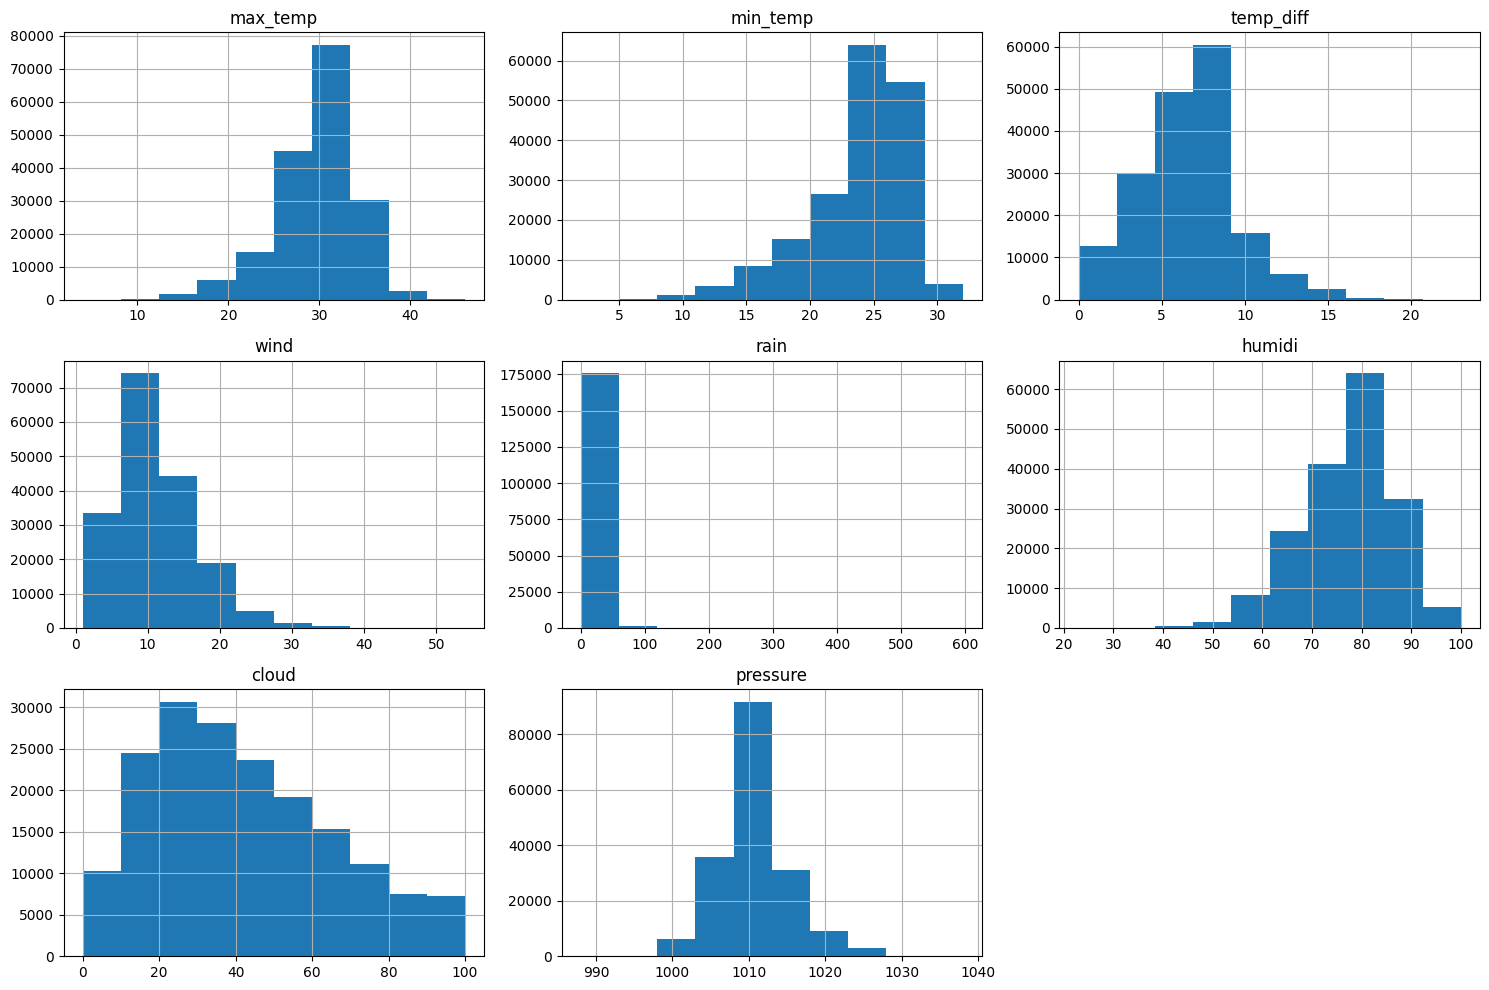

In [15]:
num_cols = ['max_temp', 'min_temp', 'temp_diff', 'wind', 'rain', 'humidi', 'cloud', 'pressure']

weather[num_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

### Boxplot (Outlier Detection)

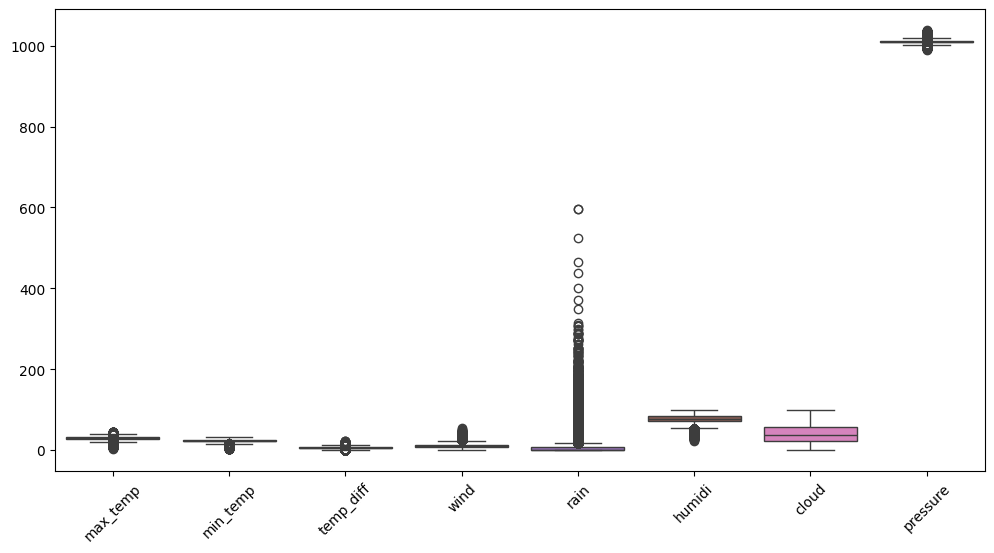

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(data=weather[num_cols])
plt.xticks(rotation=45)
plt.show()

### Outlier Detection (IQR Method)

In [17]:
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

# Report outlier counts for all numeric columns (informational only — no data is removed)
num_cols = ['max_temp', 'min_temp', 'temp_diff', 'wind', 'rain', 'humidi', 'cloud', 'pressure']
print("Outlier counts per column (IQR method — kept in dataset):")
for col in num_cols:
    n = len(detect_outliers(weather, col))
    print(f"  {col}: {n} ({n / len(weather) * 100:.2f}%)")

print("\nNOTE: All flagged values are retained — they represent real extreme weather signals.")

Outlier counts per column (IQR method — kept in dataset):
  max_temp: 8087 (4.56%)
  min_temp: 9751 (5.49%)
  temp_diff: 5633 (3.17%)
  wind: 4218 (2.38%)
  rain: 16638 (9.37%)
  humidi: 2214 (1.25%)
  cloud: 0 (0.00%)
  pressure: 13541 (7.63%)

NOTE: All flagged values are retained — they represent real extreme weather signals.


### Data Validation (Business Rules)

In [18]:
def validate_data(df):
    errors = []

    if not ((df['max_temp'] >= -10) & (df['max_temp'] <= 50)).all():
        errors.append("Max temperature out of range")

    if not ((df['min_temp'] >= -10) & (df['min_temp'] <= 50)).all():
        errors.append("Min temperature out of range")

    if not (df['temp_diff'] >= 0).all():
        errors.append("Temperature difference negative values found")

    if not ((df['humidi'] >= 0) & (df['humidi'] <= 100)).all():
        errors.append("Humidity out of range")

    if not ((df['cloud'] >= 0) & (df['cloud'] <= 100)).all():
        errors.append("Cloud out of range")

    if not (df['rain'] >= 0).all():
        errors.append("Rain negative values found")

    if not (df['pressure'] > 900).all():
        errors.append("Pressure out of range")

    return errors

errors = validate_data(weather)

if errors:
    print("Errors found:", errors)
else:
    print("All data within valid ranges")

All data within valid ranges


### Comments on Outliers in Weather Data

**The Nature of Outliers in Weather Data:**

- Points marked by IQR — especially in the `rain` column — are not noise or system errors. They accurately reflect extreme weather events such as storms, tropical depressions, or record-breaking heavy rainfall.

**Related to Model Objectives:**

- One of the expected outputs is predicting extreme weather (wind gusts, heavy rainfall). If we remove or clip these values, we inadvertently remove the most important **signals** that XGBoost and LSTM need to learn to issue warnings.

**Decision on handling:**
- **Keep all outlier values ​​unchanged.** Normalization using `MinMaxScaler` in the next step was sufficient to control the amplitude of extreme values ​​to the range `[0, 1]`, helping LSTM avoid exploding gradients during training.

# TRANSFORM DATA

## Time-dependent feature extraction (Feature extraction technique)

In [19]:
weather['day'] = weather.index.day
weather['month'] = weather.index.month
weather['year'] = weather.index.year

## Group the provinces/cities according to 4 main climate zones and assign labels

In [20]:
region_mapping = {
    'Bac Bo': ['Hoa Binh', 'Hong Gai', 'Thai Nguyen', 'Cam Pha', 'Nam Dinh', 'Uong Bi', 'Viet Tri', 'Ha Noi', 'Hai Duong', 'Yen Bai', 'Hai Phong'],
    'Trung Bo': ['Tam Ky', 'Hue', 'Thanh Hoa', 'Tuy Hoa', 'Cam Ranh', 'Nha Trang', 'Phan Rang', 'Vinh', 'Phan Thiet', 'Qui Nhon'],
    'Tay Nguyen': ['Buon Me Thuot', 'Da Lat', 'Play Cu'],
    'Nam Bo': ['Bac Lieu', 'Ho Chi Minh City', 'Ben Tre', 'Tan An', 'Bien Hoa', 'Ca Mau', 'Long Xuyen', 'Tra Vinh', 'My Tho', 'Can Tho', 'Chau Doc', 'Vinh Long', 'Vung Tau', 'Rach Gia', 'Soc Trang']
}

### Create a reverse dictionary to map each province to a region

In [21]:
prov_to_region = {prov: region for region, provs in region_mapping.items() for prov in provs}

### Add a region column

In [22]:
weather['region'] = weather['province'].map(prov_to_region)

### Encode the region into numbers (0, 1, 2, 3) to feed into the Machine Learning model

In [23]:
le_region = LabelEncoder()
weather['region_encoded'] = le_region.fit_transform(weather['region'])

In [24]:
le_province = LabelEncoder()
weather['province_encoded'] = le_province.fit_transform(weather['province'])

## Wind direction encoding (wind_d)

In [25]:
le_wind = LabelEncoder()
weather['wind_d_encoded'] = le_wind.fit_transform(weather['wind_d'])

## Remove unused text columns.

For easier searching, it is necessary to create an additional table displaying the name and corresponding code of the province before deleting the "province" column.

In [26]:
province_region_mapping = (
    weather[['province', 'region', 'province_encoded', 'region_encoded']]
    .drop_duplicates()
    .sort_values(['region_encoded', 'province_encoded'])
    .reset_index(drop=True)
)

province_region_mapping.to_csv('dataset/province_region_code_mapping.csv', index=False, encoding='utf-8-sig')

print("Province-region-code mapping exported: province_region_code_mapping.csv")

weather_transformed = weather.drop(columns=['province', 'wind_d', 'region'])
print("Data after transformation:")
display(weather_transformed.head())

Province-region-code mapping exported: province_region_code_mapping.csv
Data after transformation:


,max_temp,min_temp,wind,rain,humidi,cloud,pressure,temp_diff,day,month,year,region_encoded,province_encoded,wind_d_encoded
date,,,,,,,,,,,,,,
2009-01-01,27,22,17,6.9,90,71,1010,5,1,1,2009,1,0,5
2009-01-01,24,23,24,27.4,92,98,1012,1,1,1,2009,3,20,4
2009-01-01,24,24,29,35.5,89,99,1013,0,1,1,2009,3,32,4
2009-01-01,22,18,22,8.7,90,84,1014,4,1,1,2009,2,23,1
2009-01-01,26,21,14,3.9,93,89,1010,5,1,1,2009,1,7,8


## Separate the training/testing phases based on timeframes

In [27]:
train_data = weather_transformed[weather_transformed.index <= '2020-12-31']
test_data = weather_transformed[weather_transformed.index >= '2021-01-01']

In [28]:
print(f"\nTrain set size: {train_data.shape}")
print(f"Test set size: {test_data.shape}")


Train set size: (170937, 14)
Test set size: (6591, 14)


## Normalize numeric features

Normalization is performed after the train/test split and only fits the training set to avoid data leakage over time.

In [29]:
numeric_cols_to_scale = [
    'max_temp',
    'min_temp',
    'temp_diff',
    'wind',
    'rain',
    'humidi',
    'cloud',
    'pressure',
    'day',
    'month',
    'year'
]

scaler = MinMaxScaler()
train_data_scaled = train_data.copy()
test_data_scaled = test_data.copy()

train_data_scaled[numeric_cols_to_scale] = scaler.fit_transform(train_data[numeric_cols_to_scale])
test_data_scaled[numeric_cols_to_scale] = scaler.transform(test_data[numeric_cols_to_scale])

print('Scaled train range check:')
print(train_data_scaled[numeric_cols_to_scale].agg(['min', 'max']).round(4))

Scaled train range check:
     max_temp  min_temp  temp_diff  wind  rain  humidi  cloud  pressure  day  \
min       0.0       0.0        0.0   0.0   0.0     0.0    0.0       0.0  0.0   
max       1.0       1.0        1.0   1.0   1.0     1.0    1.0       1.0  1.0   

     month  year  
min    0.0   0.0  
max    1.0   1.0  


In [30]:
# Sort by province code first, then time within each province
# to keep each province time series contiguous in exported CSV files.
def sort_for_export(df):
    return (
        df.reset_index()
        .sort_values(['province_encoded', 'date'], ascending=[True, True])
        .set_index('date')
    )

train_data_export = sort_for_export(train_data)
test_data_export = sort_for_export(test_data)
train_data_scaled_export = sort_for_export(train_data_scaled)
test_data_scaled_export = sort_for_export(test_data_scaled)

train_data_export.to_csv('dataset/test_train/weather_train_2009_2020.csv', index=True)
test_data_export.to_csv('dataset/test_train/weather_test_2021.csv', index=True)
train_data_scaled_export.to_csv('dataset/test_train_scaled/weather_train_2009_2020_scaled.csv', index=True)
test_data_scaled_export.to_csv('dataset/test_train_scaled/weather_test_2021_scaled.csv', index=True)

print("\nCSV files successfully exported with sorting: province_encoded ASC, date ASC.")


CSV files successfully exported with sorting: province_encoded ASC, date ASC.


### Comments on Segmentation and Normalization

- Segmenting training/testing sets by time interval is accurate for time series problems as it maintains chronological order and avoids data leakage.

- Unnormalized data is still useful for Random Forest and XGBoost.

- Normalized data is a more suitable input for LSTM and rate-sensitive models.

- For Prophet, the model building team should create a separate table including `ds`, `y`, and the necessary exogenous variables for each forecasting objective.

## QA review checks

The following verification steps are used to confirm that the cleaned data is consistent for the time series modeling and supervised learning steps.

In [31]:
raw_weather = pd.read_csv(os.path.join(data_path, 'weather.csv'))
raw_weather['date'] = pd.to_datetime(raw_weather['date'])

merged_name_weather = raw_weather.copy()
merged_name_weather['province'] = merged_name_weather['province'].replace('Hanoi', 'Ha Noi')

raw_missing_dates = {}
for province, group in raw_weather.sort_values('date').groupby('province'):
    expected_dates = pd.date_range(group['date'].min(), group['date'].max(), freq='D')
    missing_count = len(expected_dates.difference(group['date']))
    if missing_count > 0:
        raw_missing_dates[province] = missing_count

review_summary = {
    'raw_shape': raw_weather.shape,
    'clean_shape': weather.shape,
    'transformed_shape': weather_transformed.shape,
    'train_shape': train_data.shape,
    'test_shape': test_data.shape,
    'raw_exact_duplicate_rows': int(raw_weather.duplicated().sum()),
    'raw_duplicate_province_date': int(raw_weather.duplicated(subset=['province', 'date']).sum()),
    'duplicate_province_date_after_name_merge': int(merged_name_weather.duplicated(subset=['province', 'date']).sum()),
    'provinces_with_missing_dates_before_imputation': len(raw_missing_dates),
    'total_missing_dates_before_imputation': int(sum(raw_missing_dates.values())),
    'province_unique_after_cleaning': weather['province'].nunique(),
    'duplicate_province_date_after_cleaning': int(weather.reset_index().duplicated(subset=['province', 'date']).sum()),
    'missing_values_after_cleaning': int(weather.isnull().sum().sum()),
    'region_missing_after_mapping': int(weather['region'].isna().sum()),
    'province_text_still_exists_in_modeling_table': 'province' in weather_transformed.columns,
    'temp_diff_column_exists': 'temp_diff' in weather_transformed.columns,
}

for key, value in review_summary.items():
    print(f'{key}: {value}')

print('\nNumeric range checks:')
print('max_temperature outside [-10, 50]:', int(((weather['max_temp'] < -10) | (weather['max_temp'] > 50)).sum()))
print('min_temperature outside [-10, 50]:', int(((weather['min_temp'] < -10) | (weather['min_temp'] > 50)).sum()))
print('temp_diff negative values:', int((weather['temp_diff'] < 0).sum()))
print('humidity outside [0, 100]:', int(((weather['humidi'] < 0) | (weather['humidi'] > 100)).sum()))
print('cloud outside [0, 100]:', int(((weather['cloud'] < 0) | (weather['cloud'] > 100)).sum()))
print('rain negative values:', int((weather['rain'] < 0).sum()))
print('pressure <= 900:', int((weather['pressure'] <= 900).sum()))

raw_shape: (181960, 10)
clean_shape: (177528, 17)
transformed_shape: (177528, 14)
train_shape: (170937, 14)
test_shape: (6591, 14)
raw_exact_duplicate_rows: 0
raw_duplicate_province_date: 0
duplicate_province_date_after_name_merge: 4549
provinces_with_missing_dates_before_imputation: 40
total_missing_dates_before_imputation: 120
province_unique_after_cleaning: 39
duplicate_province_date_after_cleaning: 0
missing_values_after_cleaning: 0
region_missing_after_mapping: 0
province_text_still_exists_in_modeling_table: False
temp_diff_column_exists: True

Numeric range checks:
max_temperature outside [-10, 50]: 0
min_temperature outside [-10, 50]: 0
temp_diff negative values: 0
humidity outside [0, 100]: 0
cloud outside [0, 100]: 0
rain negative values: 0
pressure <= 900: 0
